In [74]:
import torch 
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from einops import rearrange

In [88]:
class Sin(nn.Module):
    def __init__(self, dim, w=1, train_freq=True):
        super().__init__()
        self.freq = (
            nn.Parameter(w * torch.ones(1, dim))
            if train_freq
            else w * torch.ones(1, dim)
        )

    def forward(self, x):
        return torch.sin(self.freq * x)
    
class PositionalEmbedding(nn.Module):
    def __init__(self, emb_dim: int, seq_len: int, d_model: int, **kwargs):
        """Complex exponential positional embeddings for Hyena filters."""
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model
        # The time embedding fed to the filteres is normalized so that t_f = 1
        self.register_buffer("t", torch.linspace(0, 1, self.seq_len)[None, None, :, None])  # 1, 1, L, 1
        self.register_buffer("d", torch.linspace(0, 1, d_model)[None, :, None, None]) # 1, D, 1, 1

        if emb_dim > 1:
            bands = (emb_dim - 1) // 2
        # To compute the right embeddings we use the "proper" linspace

        t_rescaled = torch.linspace(0, seq_len - 1, seq_len)[None, None, :, None] # 1, 1, L, 1
        self.t_rescaled = t_rescaled
        d_rescaled = torch.linspace(0, d_model - 1, d_model)[None, :, None, None] # 1, D, 1, 1
        w_t = 2 * math.pi * t_rescaled / seq_len  # 1, 1, L, 1
        w_d = 2 * math.pi * d_rescaled / d_model  # 1, D, 1, 1

        # z must be a tensor of shape (1, L, D, bands)
        f = torch.linspace(1e-4, bands - 1, bands)[None, None]
        z_t = torch.exp(-1j * f * w_t) # 1, 1, L, bands
        z_d = torch.exp(-1j * f * w_d) # 1, D, 1, bands


        #z = z_t * z_d # 1, D, L, bands
        #z_t = z_t * torch.ones_like(z_d) # 1, D, L, bands
        #z_d = z_d * torch.ones_like(z_t) # 1, D, L, bands
        #self.z = nn.Parameter(torch.cat([self.t, z.real, z.imag], dim=-1))
        # fix to non-learnable
        #z = z_t
        #z = torch.cat([z.real, z.imag], dim=-1)

        z = z_t * w_d  # 1, D, L, bands
        z = torch.cat([z.real, z.imag], dim=-1)

        #z = torch.cat([self.t*torch.ones_like(self.d), self.d*torch.ones_like(self.t), z_t.real, z_t.imag, z_d.real, z_d.imag], dim=-1)
        self.register_buffer("z", z)

    def forward(self, L, D):
        return self.z[:, :D, :L], self.t[:, :D, :L]

class PositionalEmbeddingv2(nn.Module):
    def __init__(self, emb_dim: int, seq_len: int, d_model: int, **kwargs):
        """Complex exponential positional embeddings for Hyena filters."""
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model
        # The time embedding fed to the filteres is normalized so that t_f = 1
        self.register_buffer("t", torch.linspace(0, 1, self.seq_len)[None, None, :, None])  # 1, 1, L, 1
        self.register_buffer("d", torch.linspace(0, 1, d_model)[None, :, None, None]) # 1, D, 1, 1

        if emb_dim > 1:
            bands = (emb_dim - 1) // 2
        # To compute the right embeddings we use the "proper" linspace

        t_rescaled = torch.linspace(0, seq_len - 1, seq_len)[None, None, :, None] # 1, 1, L, 1
        self.t_rescaled = t_rescaled
        d_rescaled = torch.linspace(0, d_model - 1, d_model)[None, :, None, None] # 1, D, 1, 1
        w_t = 2 * math.pi * t_rescaled / seq_len  # 1, 1, L, 1
        w_d = 2 * math.pi * d_rescaled / d_model  # 1, D, 1, 1

        # z must be a tensor of shape (1, L, D * bands)
        f = torch.linspace(1e-4, bands - 1, bands)[None, None]


        z_t = torch.exp(-1j * f * w_t) # 1, 1, L, bands
        z_d = w_d # 1, D, 1, bands
        z = z_t * z_d # 1, D, L, bands
        z = rearrange(z, 'b d l c -> b l (d c)') 
        print(z.shape)
        #z = z_t * z_d # 1, D, L, bands
        #z_t = z_t * torch.ones_like(z_d) # 1, D, L, bands
        #z_d = z_d * torch.ones_like(z_t) # 1, D, L, bands
        #self.z = nn.Parameter(torch.cat([self.t, z.real, z.imag], dim=-1))
        # fix to non-learnable
        #z = z_t
        #z = torch.cat([z.real, z.imag], dim=-1)

        #z = z_t * w_d  # 1, D, L, bands
        z = torch.cat([z.real, z.imag], dim=-1)

        #z = torch.cat([self.t*torch.ones_like(self.d), self.d*torch.ones_like(self.t), z_t.real, z_t.imag, z_d.real, z_d.imag], dim=-1)
        self.register_buffer("z", z)

    def forward(self, L, D):
        return self.z[:, :, :], self.t[:, :, :]

torch.Size([1, 1024, 1024])
torch.Size([1, 1024, 64])
torch.Size([1, 1, 1024, 64])
torch.Size([1, 1, 1024, 64])


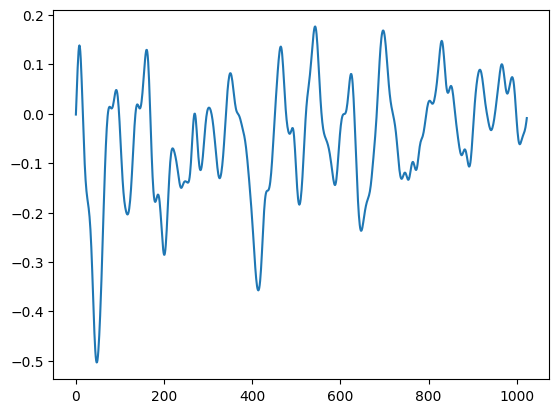

In [98]:
seq_len = 1024
d_model = 64
emb_dim = 33
pos_enc = PositionalEmbeddingv2(emb_dim, seq_len=seq_len, d_model=d_model)

z, t = pos_enc(seq_len, d_model)

# t = torch.linspace(0, seq_len - 1, seq_len)[None, None, :, None] # 1, 1, L, 1
# d = torch.linspace(0, d_model - 1, d_model)[None, :, None, None] # 1, D, 1, 1
# t = t * torch.ones_like(d)
# d = d * torch.ones_like(t)
# z = torch.cat([t, d, t*d], dim=-1)


f = nn.Sequential(
    nn.Linear(d_model * (emb_dim - 1), 10 * emb_dim),
    Sin(10 * emb_dim),
    nn.Linear(10 * emb_dim, 10 * emb_dim),
    Sin(10 * emb_dim),
    nn.Linear(10 * emb_dim, d_model),
)

print(f(z).shape)
h = f(z) * torch.exp(-0.001 * pos_enc.t_rescaled)
print(h.shape)

print(h.shape)
for i in range(1):
    plt.plot(h[0,0,:,i].detach().numpy())

In [80]:
seq_len = 1024
d_model = 64
emb_dim = 33
pos_enc = PositionalEmbeddingv2(emb_dim, seq_len=seq_len, d_model=d_model)

z, t = pos_enc(seq_len, d_model)

# t = torch.linspace(0, seq_len - 1, seq_len)[None, None, :, None] # 1, 1, L, 1
# d = torch.linspace(0, d_model - 1, d_model)[None, :, None, None] # 1, D, 1, 1
# t = t * torch.ones_like(d)
# d = d * torch.ones_like(t)
# z = torch.cat([t, d, t*d], dim=-1)


f = nn.Sequential(
    nn.Linear(d_model * (emb_dim - 1), 10 * emb_dim),
    Sin(10 * emb_dim),
    nn.Linear(10 * emb_dim, 10 * emb_dim),
    Sin(10 * emb_dim),
    nn.Linear(10 * emb_dim, 1),
)

print(f(z).shape)
h = f(z) * torch.exp(-0.001 * pos_enc.t_rescaled)
print(h.shape)

print(h.shape)
for i in range(10):
    plt.plot(h[0,i].detach().numpy())

torch.Size([1, 1024, 1024])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x1024 and 2048x330)